In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from constants import ESPN_OUTPUT_DIRECTORY, ESPN_OUTPUT_NAME
from score_espn import initial_parse_espn, score_espn
import pandas as pd

In [3]:
NUM_CORES = 20

In [4]:
# # 2021
# MANUAL_BRACKET = [
#     1, 3, 5, 8, 9, 11, 13, 15,
#     17, 19, 21, 23, 26, 28, 30, 31,
#     33, 36, 37, 40, 41, 43, 45, 48,
#     49, 51, 54, 55, 58, 59, 62, 63,
#     1, 5, 9, 13,
#     17, 23, 26, 31,
#     33, 37, 43, 48,
#     51, 54, 58, 63,
#     1, 9,
#     17, 26,
#     33, 43,
#     54, 63,
#     1, 26, 33, 63,
#     1, 33,
#     33,
# ]
# # 2022
# MANUAL_BRACKET = [
#     1, 4, 6, 7, 10, 11, 13, 15,
#     17, 19, 21, 23, 25, 27, 29, 32,
#     33, 36, 37, 39, 42, 43, 45, 47,
#     49, 52, 54, 55, 58, 59, 62, 63,
#     1, 7, 11, 15,
#     19, 23, 27, 32,
#     33, 37, 42, 47,
#     49, 55, 58, 62,
#     7, 15,
#     19, 32,
#     37, 47,
#     49, 62,
#     15, 19, 47, 49,
#     19, 49,
#     49,
# ]

# 2023
MANUAL_BRACKET = {
    "mens": [
        1, 3, 5, 8, 9, 11, 13, 16,
        18, 20, 21, 23, 25, 27, 29, 31,
        33, 36, 37, 39, 42, 43, 46, 47,
        49, 51, 53, 55, 57, 59, 61, 63,
        1, 5, 9, 16,
        20, 23, 27, 29,
        33, 37, 43, 47,
        51, 55, 59, 63,
        5, 9,
        20, 27,
        37, 47,
        55, 59,
        5, 20, 37, 55,
        5, 55,
        55,
    ],
    "womens": [
        1, 3, 5, 7, 10, 11, 13, 15,
        17, 19, 21, 23, 25, 27, 30, 31,
        33, 36, 38, 39, 41, 43, 46, 47,
        49, 52, 54, 55, 57, 59, 61, 63,
        1, 7, 11, 15,
        19, 21, 25, 31,
        36, 39, 43, 47,
        49, 55, 59, 63,
        1, 15,
        21, 31,
        36, 43,
        49, 59,
        1, 31, 43, 49,
        31, 43,
        43,
    ]
}

In [5]:
GENDER = "mens"

### Test against a couple brackets to check manual entry

In [29]:
%%time
from score_espn import parse_espn, score_espn_bracket, create_actual_bracket
import os
filenames = [
    os.path.join(ESPN_OUTPUT_DIRECTORY.format(gender=GENDER), file)
    for file in os.listdir(ESPN_OUTPUT_DIRECTORY.format(gender=GENDER))
    if not file.startswith(".")
]
brackets = parse_espn(filenames[-1], 0)
actual_bracket = create_actual_bracket(manual_bracket=MANUAL_BRACKET[GENDER])
scored_brackets = [
    score_espn_bracket(bracket, actual_bracket=actual_bracket)
    for bracket in list(brackets.values())[:10]
]
pd.DataFrame(scored_brackets)

/Volumes/3TB/bracket-data/2023/mens/espn_brackets_2023/espn_brackets_leaderboard.json: 63742.825796107
CPU times: user 92.1 ms, sys: 174 ms, total: 267 ms
Wall time: 325 ms


,id,score
0,84192525,1310
1,86687561,1290
2,90101195,1290
3,77211633,1600
4,76143483,1280
5,89768899,1600
6,84071956,1580
7,92365135,1580
8,83955843,1570
9,88707945,1570


### Only need to run this once
Didn't seem to like running this as a loop?

In [6]:
%%time
# for gender in ["mens", "womens"]:
num_cores = 15
gender = "mens"
initial_parse_espn(
    ESPN_OUTPUT_DIRECTORY.format(gender=gender),
    ESPN_OUTPUT_NAME.format(gender=gender),
    num_cores=num_cores,
    num_files=None
)

CPU times: user 5min 18s, sys: 10min 43s, total: 16min 2s
Wall time: 23min 8s


### Score brackets

In [6]:
%%time
score_espn(ESPN_OUTPUT_NAME.format(gender=GENDER), MANUAL_BRACKET[GENDER], num_cores=NUM_CORES)

CPU times: user 3min 36s, sys: 2min 49s, total: 6min 26s
Wall time: 7min 47s


In [7]:
test = pd.read_feather(f"{ESPN_OUTPUT_NAME.format(gender=GENDER)}.feather")
test.head()

,id,score
0,87849367,1010
1,84786443,920
2,86789087,750
3,85019830,1220
4,90253116,740


In [8]:
test.shape

(10421621, 2)

In [9]:
test.sort_values("score").tail(10)

,id,score
10421584,92220065,1560
8729107,87365381,1560
2071818,89312580,1560
2071740,83955843,1570
10421583,81702739,1570
8326889,88707945,1570
10421582,92365135,1580
2071557,84071956,1580
2071549,89768899,1600
353838,77211633,1600


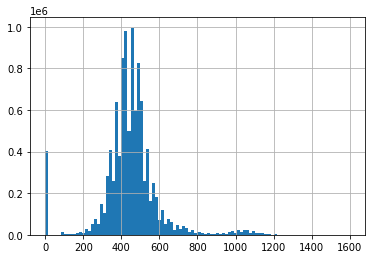

In [10]:
test["score"].hist(bins=100)

# Hypothetical Situation
## Arkansas wins out

In [5]:
MANUAL_BRACKET = [
    1, 3, 5, 8, 9, 11, 13, 15,
    17, 19, 21, 23, 26, 28, 30, 31,
    33, 36, 37, 40, 41, 43, 45, 48,
    49, 51, 54, 55, 58, 59, 62, 63,
    1, 5, 9, 13,
    17, 23, 26, 31,
    33, 37, 43, 48,
    51, 54, 58, 63,
    1, 9,
    17, 26,
    33, 43,
    54, 63,
    1, 26, 43, 63,
    1, 43,
    43,
]

### Score brackets

In [7]:
%%time
score_espn(ESPN_OUTPUT_NAME, MANUAL_BRACKET, num_cores=NUM_CORES, new_name="espn_hypothetical")

CPU times: user 2min 35s, sys: 1min 41s, total: 4min 17s
Wall time: 5min 5s


In [11]:
test = pd.read_feather("espn_hypothetical.feather")
test.head()

,id,score
0,41116027,910
1,43553238,750
2,37179442,650
3,40348440,1200
4,42270570,470


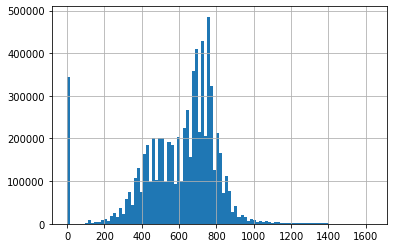

In [12]:
test["score"].hist(bins=100)